# Assignment 1

### 1.1


In [78]:
import pandas as pd
df = pd.read_stata("data/A1_kommune.dta")

In [79]:
df[['taxrev', 'taxrate', 'pop']].describe().T

,count,mean,std,min,25%,50%,75%,max
taxrev,98.0,4477.341309,5251.175293,211.228409,2466.702271,3317.848633,4786.060913,44170.335938
taxrate,98.0,25.208162,0.908003,22.799999,24.799999,25.299999,25.700001,27.799999
pop,98.0,56475.887755,62925.301713,1969.000000,29997.750000,43475.000000,59733.000000,528208.000000


### 2.1 log($taxrev_m$) = $\delta_0$ + $\delta_1$ $taxrate_m$ + $\epsilon_m$

                            OLS Regression Results                            
Dep. Variable:             log_taxrev   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     2.818
Date:                Thu, 17 Sep 2026   Prob (F-statistic):             0.0965
Time:                        22:04:05   Log-Likelihood:                -111.12
No. Observations:                  98   AIC:                             226.2
Df Residuals:                      96   BIC:                             231.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.6982      2.143      5.459      0.0

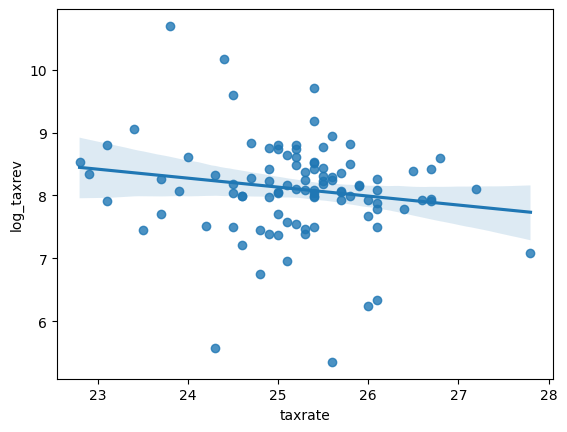

In [80]:
import numpy as np
import statsmodels.api as sm
import seaborn as sns
df['log_taxrev'] = np.log(df['taxrev'])
y = df['log_taxrev']
X = df['taxrate']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())
sns.regplot(data=df, x='taxrate', y='log_taxrev')
results = pd.DataFrame({
    'Estimate': model.params,
    'Std. Error': model.bse
})
print(results.round(4))

### 2.2 log($taxrev_m$) = $beta_0$ + $\beta_1$ $taxrate_m$ + $\beta_2$ log($pop_m$) + $u_m$



In [81]:

df['log_taxrev'] = np.log(df['taxrev'])
df['log_pop'] = np.log(df['pop'])
y = df['log_taxrev']
X = df[['taxrate', 'log_pop']]
X = sm.add_constant(X)
model2 = sm.OLS(y, X).fit()
print(model2.summary())
cov_matrix = np.cov(df['taxrate'], df['log_pop'])
vartaxrate = cov_matrix[0, 0]
covtaxpop = cov_matrix[0, 1]
beta2_hat = model2.params['log_pop']
bias = beta2_hat * (covtaxpop / vartaxrate)
print("Var(taxrate):", vartaxrate)
print("Cov(taxrate, log_pop):", covtaxpop)
print("beta2:", beta2_hat)
print("bias eller OVB", bias)

                            OLS Regression Results                            
Dep. Variable:             log_taxrev   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     2344.
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           1.42e-81
Time:                        22:04:05   Log-Likelihood:                 79.497
No. Observations:                  98   AIC:                            -153.0
Df Residuals:                      95   BIC:                            -145.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.8022      0.376     -7.461      0.0


### 3.3 $taxrate_m = \gamma_0 + \gamma_1 \log(pop_m) + r_m $

In [82]:
df['log_pop'] = np.log(df['pop'])
y1 = df['taxrate']
X1 = df[['log_pop']]
X1 = sm.add_constant(X1)
results1 = sm.OLS(y1, X1).fit()
print(results1.summary())
df['res1'] = results1.resid
print(df['res1'])

                            OLS Regression Results                            
Dep. Variable:                taxrate   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     3.862
Date:                Thu, 17 Sep 2026   Prob (F-statistic):             0.0523
Time:                        22:04:05   Log-Likelihood:                -127.16
No. Observations:                  98   AIC:                             258.3
Df Residuals:                      96   BIC:                             263.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         27.6268      1.234     22.386      0.0

In [83]:
y2 = df['log_taxrev']
X2 = df[['res1']]
X2 = sm.add_constant(X2)
results2 = sm.OLS(y2, X2).fit()
print(results2.summary())

                            OLS Regression Results                            
Dep. Variable:             log_taxrev   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                   0.06626
Date:                Thu, 17 Sep 2026   Prob (F-statistic):              0.797
Time:                        22:04:05   Log-Likelihood:                -112.50
No. Observations:                  98   AIC:                             229.0
Df Residuals:                      96   BIC:                             234.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.1031      0.078    104.100      0.0

In [84]:
print("beta1 fra multiple regression:", model2.params['taxrate'])
print("beta1 fra residual regression:", results2.params['res1'])

beta1 fra multiple regression: 0.02262226405831025
beta1 fra residual regression: 0.022622264058311248


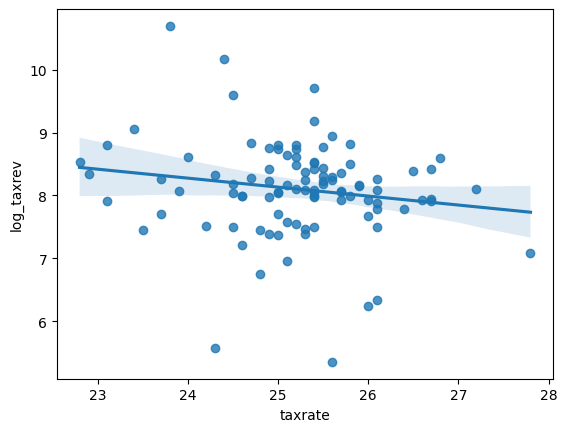

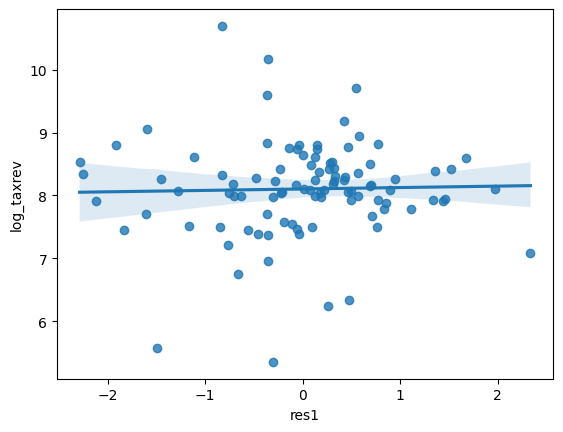

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.regplot(data=df, x='taxrate', y='log_taxrev')
plt.show()
sns.regplot(data=df, x='res1', y='log_taxrev')
plt.show()
